In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Load Data

In [ ]:
# load in cleaned dataset
train = pd.read_csv('data/train_cleaned.csv')
test = pd.read_csv('data/test_cleaned.csv')
y = train[["SalePrice"]]
test_ids = test['Id'] # for submit to kaggle

train.drop(columns=["Id","SalePrice"],inplace=True)
test.drop(columns=["Id"],inplace=True)

# train test split
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Selection

<Axes: >

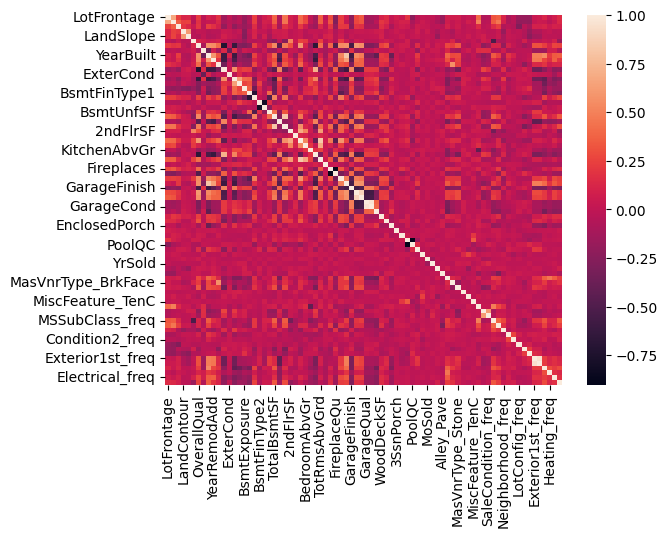

In [27]:
# this is removing the feature by correlation
corr = train.corr()
sns.heatmap(corr)
# # triangle matrix for delete
# corr = train.corr().abs()
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# # columns to drop
# to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]
# train.drop(columns=to_drop, inplace=True)

In [ ]:
# # area is large, log to lower the numbers
# train['LotArea']=np.log(train['LotArea']+1)

from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.3141076552842453
R^2:  0.8436209489965238


In [14]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
reg = LinearRegression().fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.3141076552842453
R^2:  0.8436209489965238


In [ ]:


def stepwise_aic(X, y, initial_features=None):
    included = list(initial_features) if initial_features else []

    def aic_of(features):
        if not features:
            return np.inf
        return sm.OLS(y, sm.add_constant(X[features])).fit().aic

    current_aic = aic_of(included)

    while True:
        changed = False

        # forward
        excluded = list(set(X.columns) - set(included))
        add_candidates = {col: aic_of(included + [col]) for col in excluded}
        if add_candidates:
            best_add_feature = min(add_candidates, key=add_candidates.get)
            best_add_aic = add_candidates[best_add_feature]
        else:
            best_add_feature, best_add_aic = None, np.inf

        # backward
        remove_candidates = {col: aic_of([c for c in included if c != col]) for col in included}
        if remove_candidates:
            best_remove_feature = min(remove_candidates, key=remove_candidates.get)
            best_remove_aic = remove_candidates[best_remove_feature]
        else:
            best_remove_feature, best_remove_aic = None, np.inf

        # print best move
        best_move_aic = min(best_add_aic, best_remove_aic, current_aic)

        if best_move_aic < current_aic:
            if best_add_aic < best_remove_aic:
                included.append(best_add_feature)
                current_aic = best_add_aic
                changed = True
                print(f"Add    {best_add_feature:>20} → AIC = {best_add_aic:.2f}")
            else:
                included.remove(best_remove_feature)
                current_aic = best_remove_aic
                changed = True
                print(f"Remove {best_remove_feature:>20} → AIC = {best_remove_aic:.2f}")

        if not changed:
            break

    return included

In [21]:
included = stepwise_aic(X_train,y_train)


Add             OverallQual → AIC = 28488.02
Add               GrLivArea → AIC = 28192.60
Add              BsmtFinSF1 → AIC = 28069.49
Add              GarageCars → AIC = 27960.48
Add               ExterQual → AIC = 27885.89
Add                 LotArea → AIC = 27808.62
Add             KitchenQual → AIC = 27774.31
Add            BsmtExposure → AIC = 27749.20
Add         MSSubClass_freq → AIC = 27713.61
Add       Neighborhood_freq → AIC = 27680.89
Add         Condition1_freq → AIC = 27663.18
Add             LotFrontage → AIC = 27652.50
Add              Functional → AIC = 27640.72
Add             FireplaceQu → AIC = 27630.09
Add              GarageCond → AIC = 27621.63
Add            BsmtFinType1 → AIC = 27614.30
Add          RoofStyle_freq → AIC = 27606.19
Add                BsmtQual → AIC = 27599.79
Add             OverallCond → AIC = 27592.98
Add                BsmtCond → AIC = 27581.15
Add              MasVnrArea → AIC = 27575.28
Add      MasVnrType_BrkFace → AIC = 27562.95
Add       

In [52]:
#on9 aic will underfit model 
#use with caution
train = train[['OverallQual', 'GrLivArea', 'BsmtFinSF1', 'GarageCars', 'ExterQual', 'MSSubClass_freq', 'BsmtExposure', 'KitchenQual', 'Neighborhood_freq', 'Condition1_freq', 'Fireplaces', 'Functional', 'LotArea', 'RoofStyle_freq', 'No. of bathrooms', 'BldgType_freq', 'HouseStyle', 'MasVnrArea', 'OverallCond', 'BsmtQual', 'BsmtCond']]
test = test[['OverallQual', 'GrLivArea', 'BsmtFinSF1', 'GarageCars', 'ExterQual', 'MSSubClass_freq', 'BsmtExposure', 'KitchenQual', 'Neighborhood_freq', 'Condition1_freq', 'Fireplaces', 'Functional', 'LotArea', 'RoofStyle_freq', 'No. of bathrooms', 'BldgType_freq', 'HouseStyle', 'MasVnrArea', 'OverallCond', 'BsmtQual', 'BsmtCond']]


In [13]:

from sklearn.tree import DecisionTreeRegressor
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
reg = DecisionTreeRegressor().fit(X_train,y_train)
y_pred = reg.predict(X_test)
np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred)))
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test,y_test))

0.22500147943748008
R^2:  0.7749060300771838


In [14]:
import xgboost as xgb

X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.13708934533545125
R^2:  0.9118821037842014


In [166]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
    min_child_weight=5,
    max_depth=5,
    reg_lambda=1,
    n_estimators=250, 
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.1301114725508227
R^2:  0.9184968046528881


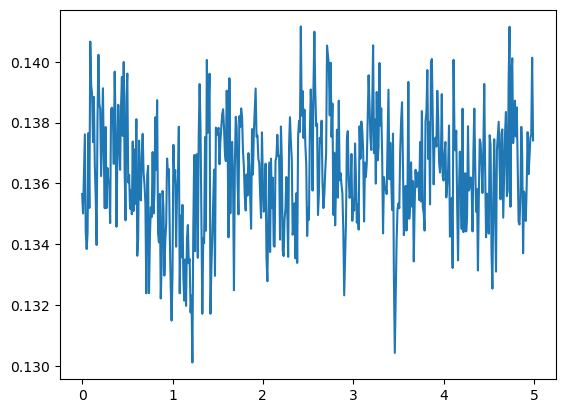

In [155]:
lambdas = []
errors = []
for i in range(500):
    model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
        min_child_weight=5,
        max_depth=5,
        reg_lambda=i/100,
        n_estimators=250, 
        random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    lambdas.append(i/100)
    errors.append(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))


In [167]:
errors.index(min(errors))
lambdas[errors.index(min(errors))]

1.22

In [176]:
estimators = []
errors = []
for i in range(200):
    model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
        min_child_weight=5,
        max_depth=5,
        reg_lambda=1.22,
        n_estimators=150+i, 
        random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    estimators.append(i)
    errors.append(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))


In [178]:
errors.index(min(errors))
estimators[errors.index(min(errors))]

5

In [179]:
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.1,
    min_child_weight=5,
    max_depth=5,
    reg_lambda=1.22,
    n_estimators=155, 
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',model.score(X_test,y_test))

0.12928888900843716
R^2:  0.9177386817717241


In [33]:
pd.Series(pred).to_csv("test1.csv")